<a href="https://colab.research.google.com/github/elsolimecanico/Reconstrucci-n-de-Campos-de-Flujo-con-Super-Resoluci-n-mediante-CNNs-con-F-sica-Incorporada/blob/main/fase1_generacion_dataset_cylinder_wake_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 1 — Generación del dataset: Cylinder Wake 2D con PhiFlow

**Proyecto:** Reconstrucción de campos de flujo con IA (Super-Resolución de Fluidos)

**Objetivo de este notebook:** generar pares de datos (baja resolución / alta resolución) del caso clásico de flujo alrededor de un cilindro (Kármán vortex street), que servirán como dataset de entrenamiento para la red de super-resolución en la Fase 2.

**Por qué este caso:** es el mismo benchmark que usan Fukami et al. (2019, 2021) en los papers fundacionales del área — simple de simular, pero con física interesante (desprendimiento de vórtices) que una CNN puede aprender a reconstruir.

**Nota importante:** este notebook usa PhiFlow 3.x. La API de PhiFlow ha cambiado entre versiones en el pasado, así que si algún comando falla, lo primero es revisar la versión instalada (`phi.__version__`) contra la documentación en https://tum-pbs.github.io/PhiFlow/. Esto es normal al trabajar con librerías de investigación — parte del proceso es debuggear.

## 1. Instalación

Corre esta celda primero. Como estamos en Colab, no necesitamos instalar CUDA aparte — solo verifica que tengas GPU activada: `Entorno de ejecución > Cambiar tipo de entorno de ejecución > GPU (T4)`.

In [ ]:
!pip install --upgrade --quiet phiflow

import phi
print("PhiFlow version:", phi.__version__)

from phi.flow import *
import numpy as np
import matplotlib.pyplot as plt
import os

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.4/207.4 kB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.2/378.2 kB 26.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
PhiFlow version: 3.4.0


## 2. Configuración del dominio y del cilindro

Definimos:
- Un dominio rectangular (canal) por donde entra el flujo.
- Un obstáculo circular (el cilindro) que genera el desprendimiento de vórtices.
- Una velocidad de entrada constante desde el lado izquierdo.

La resolución `RES_X x RES_Y` es la resolución "alta" (ground truth). De aquí derivaremos después la versión de baja resolución por downsampling.

In [ ]:
# --- Parámetros del dominio ---
RES_X, RES_Y = 128, 64          # resolución alta (ground truth)
DOMAIN_X, DOMAIN_Y = 256, 128   # tamaño físico del dominio

NU = 0.01          # viscosidad cinemática (controla el Reynolds efectivo)
DT = 0.5           # paso de tiempo
INFLOW_SPEED = 1.0 # velocidad de entrada uniforme (eje x)

CYL_RADIUS = 8
CYL_CENTER = (DOMAIN_X * 0.25, DOMAIN_Y * 0.5)  # cilindro cerca de la entrada

# --- Obstáculo (el cilindro) ---
CYLINDER = Obstacle(Sphere(center=tensor(CYL_CENTER, channel(vector='x,y')), radius=CYL_RADIUS))

# --- Campo de velocidad inicial (staggered grid, estándar para Navier-Stokes en PhiFlow) ---
velocity = StaggeredGrid(
    (INFLOW_SPEED, 0),
    extrapolation.BOUNDARY,
    x=RES_X, y=RES_Y,
    bounds=Box(x=(0, DOMAIN_X), y=(0, DOMAIN_Y))
)

print("Dominio configurado:", velocity.shape)

Dominio configurado: (xˢ=128, yˢ=64, vectorᶜ=x,y)


## 3. Función de avance temporal (un paso de simulación)

Cada paso hace lo mismo que cualquier solver de Navier-Stokes incompresible:
1. **Advección**: el campo de velocidad se transporta a sí mismo.
2. **Difusión**: efecto de la viscosidad.
3. **Proyección de presión** (`make_incompressible`): corrige el campo para que sea libre de divergencia, respetando el obstáculo (no-slip en el cilindro).

In [ ]:
def step(velocity, dt=DT):
    velocity = advect.semi_lagrangian(velocity, velocity, dt)
    velocity = diffuse.explicit(velocity, NU, dt)
    velocity, pressure = fluid.make_incompressible(velocity, (CYLINDER,), Solve('CG', 1e-3))
    return velocity, pressure

# Prueba: un solo paso, para verificar que no hay errores antes de correr todo
velocity, pressure = step(velocity)
print("Un paso ejecutado correctamente.")
print("Velocidad máxima:", math.max(velocity.values))

Un paso ejecutado correctamente.
Velocidad máxima: 1.6312369


## 4. Correr la simulación y guardar snapshots

Vamos a:
- Correr varios cientos de pasos para dejar que el flujo se desarrolle (el desprendimiento de vórtices tarda un poco en aparecer — los primeros pasos no sirven como dato de entrenamiento, hay que descartarlos).
- Guardar un snapshot cada cierto número de pasos, una vez que el flujo ya está en régimen periódico (vortex shedding establecido).

**Nota:** si `N_WARMUP` y `N_STEPS` te resultan muy lentos en Colab, bájalos primero para probar que todo funciona, y luego sube los valores para el dataset final.

In [ ]:
N_WARMUP = 200      # pasos para dejar que se desarrolle el vortex shedding (no se guardan)
N_STEPS = 400        # pasos donde SÍ guardamos snapshots
SAVE_EVERY = 2       # guarda 1 de cada N pasos (para tener frames suficientemente distintos)

snapshots_ux = []
snapshots_uy = []

print("Fase de warmup (no se guarda nada)...")
for i in range(N_WARMUP):
    velocity, pressure = step(velocity)
    if i % 50 == 0:
        print(f"  warmup step {i}/{N_WARMUP}")

print("Fase de captura de snapshots...")
for i in range(N_STEPS):
    velocity, pressure = step(velocity)
    if i % SAVE_EVERY == 0:
        # FIX: usamos at_centers() para que ux y uy queden en la MISMA malla
        # (StaggeredGrid guarda ux/uy en caras desplazadas medio paso de celda,
        # lo que produce shapes distintos como (64,129) vs (65,128)).
        centered = velocity.at_centers()
        ux = centered.vector['x'].values.numpy('y,x')
        uy = centered.vector['y'].values.numpy('y,x')
        snapshots_ux.append(ux)
        snapshots_uy.append(uy)
    if i % 50 == 0:
        print(f"  capture step {i}/{N_STEPS}, snapshots guardados: {len(snapshots_ux)}")

snapshots_ux = np.array(snapshots_ux)  # shape: (n_frames, RES_Y_ish, RES_X_ish)
snapshots_uy = np.array(snapshots_uy)

print("Forma final del dataset:")
print("  ux:", snapshots_ux.shape)
print("  uy:", snapshots_uy.shape)

Fase de warmup (no se guarda nada)...
  warmup step 0/200
  warmup step 50/200
  warmup step 100/200
  warmup step 150/200
Fase de captura de snapshots...
  capture step 0/400, snapshots guardados: 1
  capture step 50/400, snapshots guardados: 26
  capture step 100/400, snapshots guardados: 51
  capture step 150/400, snapshots guardados: 76
  capture step 200/400, snapshots guardados: 101
  capture step 250/400, snapshots guardados: 126
  capture step 300/400, snapshots guardados: 151
  capture step 350/400, snapshots guardados: 176
Forma final del dataset:
  ux: (200, 64, 128)
  uy: (200, 64, 128)


## 5. Visualizar un snapshot (verificación visual)

Antes de seguir, siempre visualiza — si el cilindro y el desprendimiento de vórtices no se ven razonables aquí, no tiene sentido seguir a la siguiente fase.

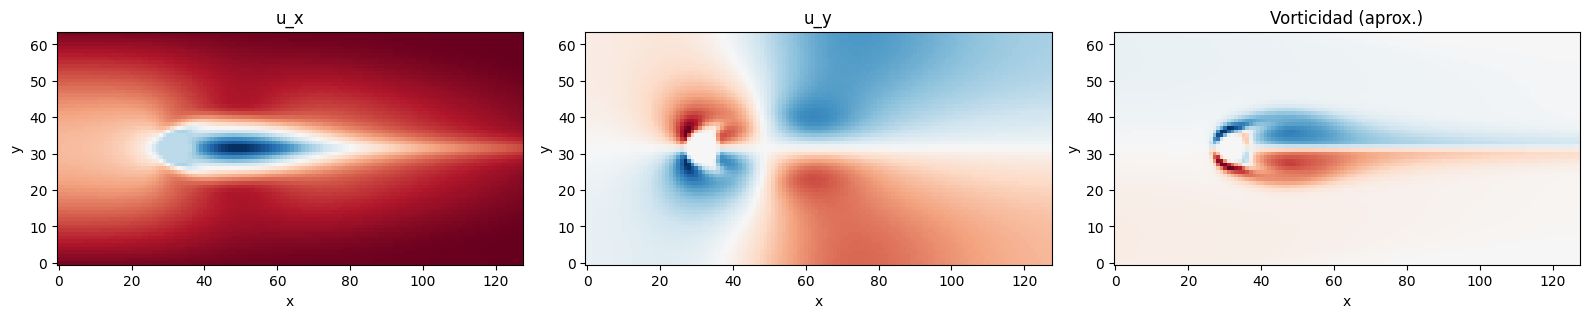

Si ves un patrón de vórtices alternados detrás del cilindro en el panel de vorticidad, la simulación va bien.


In [ ]:
idx = -1  # último snapshot capturado

# Gracias al fix con at_centers() en la celda anterior, ux y uy ya
# tienen exactamente la misma forma -- ya no hace falta interpolar nada aquí.
ux_snapshot = snapshots_ux[idx]
uy_snapshot = snapshots_uy[idx]
assert ux_snapshot.shape == uy_snapshot.shape, "ux y uy deberían calzar ahora; revisa la celda de captura"

vorticity = np.gradient(uy_snapshot, axis=1) - np.gradient(ux_snapshot, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].imshow(ux_snapshot, origin='lower', cmap='RdBu_r')
axes[0].set_title('u_x')
axes[1].imshow(uy_snapshot, origin='lower', cmap='RdBu_r')
axes[1].set_title('u_y')
axes[2].imshow(vorticity, origin='lower', cmap='RdBu_r')
axes[2].set_title('Vorticidad (aprox.)')
for ax in axes:
    ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.show()

print("Si ves un patrón de vórtices alternados detrás del cilindro en el panel de vorticidad, la simulación va bien.")

## 6. Generar los pares baja resolución / alta resolución

Esta es la parte central para el proyecto de super-resolución: a partir de cada snapshot de alta resolución, generamos su versión de baja resolución por *downsampling* (tomando 1 de cada `DOWNSAMPLE_FACTOR` puntos). Esto simula tener pocos sensores o una malla CFD gruesa.

In [ ]:
DOWNSAMPLE_FACTOR = 4  # factor de reducción (4x menos resolución en cada eje)

def downsample(field, factor):
    return field[::factor, ::factor]

low_res_ux = np.array([downsample(f, DOWNSAMPLE_FACTOR) for f in snapshots_ux])
low_res_uy = np.array([downsample(f, DOWNSAMPLE_FACTOR) for f in snapshots_uy])

print("Alta resolución:", snapshots_ux.shape)
print("Baja resolución:", low_res_ux.shape)
print(f"Factor de compresión: ~{DOWNSAMPLE_FACTOR**2}x menos datos")

Alta resolución: (200, 64, 128)
Baja resolución: (200, 16, 32)
Factor de compresión: ~16x menos datos


## 7. Guardar el dataset

Guardamos todo como arrays de numpy. Puedes montar tu Google Drive para que el dataset persista entre sesiones de Colab (si no, se borra al cerrar el entorno de ejecución).

In [ ]:
from google.colab import drive
import os
import numpy as np

# 1. Esto conectará tu Google Drive con Colab
drive.mount('/content/drive')

# 2. Definimos la ruta permanente dentro de tu Drive
OUTPUT_DIR = '/content/drive/MyDrive/proyecto_fluidos'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 3. Guardamos los archivos directamente en tu Drive
np.save(os.path.join(OUTPUT_DIR, 'high_res_ux.npy'), snapshots_ux)
np.save(os.path.join(OUTPUT_DIR, 'high_res_uy.npy'), snapshots_uy)
np.save(os.path.join(OUTPUT_DIR, 'low_res_ux.npy'), low_res_ux)
np.save(os.path.join(OUTPUT_DIR, 'low_res_uy.npy'), low_res_uy)

print(f"¡Hecho! Dataset guardado permanentemente en tu Google Drive en la carpeta: {OUTPUT_DIR}")

Mounted at /content/drive
¡Hecho! Dataset guardado permanentemente en tu Google Drive en la carpeta: /content/drive/MyDrive/proyecto_fluidos
